In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import seaborn as sns

# Доверительные интервалы

1) Построить график функции y1−α+β − yβ для β ∈ (0, α), где yt – квантиль распределения

(a) N(0, 1),

(b) Gamma(n, 1), n = 1, 2, 5, 10, 100,

(c) R[0, 1],

(d) Beta(a, b), a = b = 5, a = 10, b = 2, a = 20, b = 1.

Рассмотреть одно любое значение α, например, α = 0.001, 0.05, 0.1. Сделать вывод о выборе оп-
тимального β для построения доверительного интервала на основе статистики с нашим распреде-
лением.

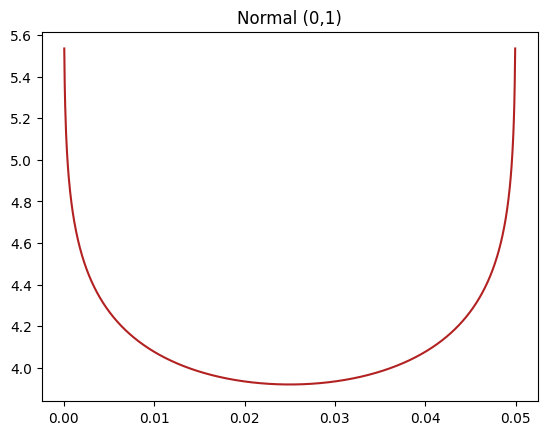

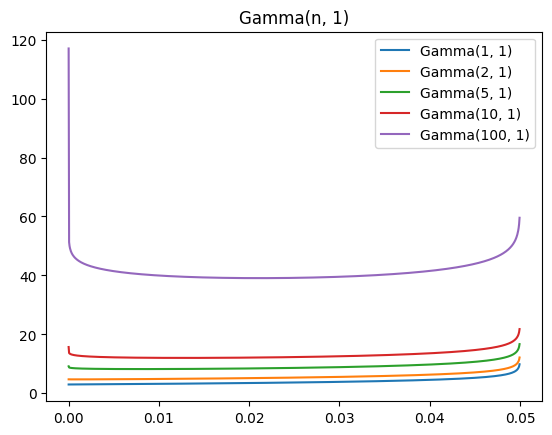

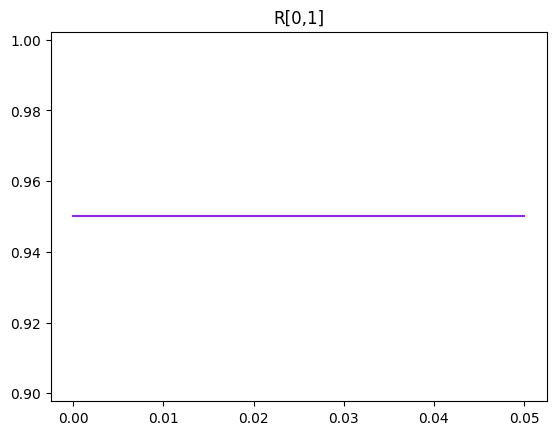

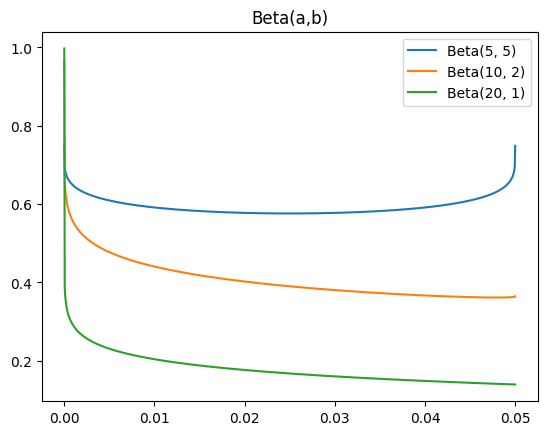

In [ ]:
a = 0.05
beta = np.linspace(0, a, 1000)
y = stats.norm.ppf(1-a+beta) - stats.norm.ppf(beta)
plt.plot(beta, y, color = 'firebrick')
plt.title('Normal (0,1)')
plt.show()

n_val = [1,2,5,10,100]
for n in n_val:
  y = stats.gamma.ppf(1-a+beta, n) - stats.gamma.ppf(beta, n)
  plt.plot(beta, y, label = f'Gamma({n}, 1)')
plt.legend()
plt.title("Gamma(n, 1)")
plt.show()

y = stats.uniform.ppf(1-a+beta) - stats.uniform.ppf(beta, 0, 1)
plt.plot(beta, y, color = 'blueviolet')
plt.title('R[0,1]')
plt.show()

params = [[5,5], [10, 2], [20, 1]]
for p in params:
  y = stats.beta.ppf(1-a+beta, p[0], p[1]) - stats.beta.ppf(beta, p[0], p[1])
  plt.plot(beta, y, label = f'Beta({p[0]}, {p[1]})')
plt.legend()
plt.title('Beta(a,b)')
plt.show()

2) X1, ..., Xn ∼ R[0, θ].

(a) Построить асимптотический доверительный интервал, используя X. Найти эмпирически доверительную вероятность этого интервала (построить 1000 выборок, подсчитать долю тех, для которых интервал накрыл истинное значение параметра, для n = 20, 50, 100.

(b) Построить точный доверительный интервал, используя достаточную статистику. Сравнить
средние длины точного и асимптотического интервалов при n = 20, 50, 100.

In [ ]:
n_val = [20,50, 100, 500]
k = 1000
theta = 4
a = 0.05

for n in n_val:
  empirical_credit = 0
  len_check = 0
  for i in range(k):
    x_data = stats.uniform.rvs(0, theta, size = n)

    var = (2*np.mean(x_data))/np.sqrt(3*n)
    asymp_low = 2*np.mean(x_data) - stats.norm.ppf(1-a/2)*var
    asymp_up = 2*np.mean(x_data) + stats.norm.ppf(1-a/2)*var
    if asymp_low < theta < asymp_up:
      empirical_credit +=1


    x_max = max(x_data)
    exact_low = x_max / ((a/2)**(1/n))
    exact_up = x_max/((1-a/2)**(1/n))
    if exact_up - exact_low < asymp_up - asymp_low:
      len_check += 1
  print(f"For n = {n} : empirical_coverage for asymptotic: {empirical_credit / k}")
  print(f"             exact interval was shorter in {len_check / k} cases")


For n = 20 : empirical_coverage for asymptotic: 0.935
             exact interval was shorter in 1.0 cases
For n = 50 : empirical_coverage for asymptotic: 0.95
             exact interval was shorter in 1.0 cases
For n = 100 : empirical_coverage for asymptotic: 0.957
             exact interval was shorter in 1.0 cases
For n = 500 : empirical_coverage for asymptotic: 0.959
             exact interval was shorter in 1.0 cases


3) X1, ..., Xn ∼ Bern(θ).

а) Построить асимптотический доверительный интервал двумя способами
с помощью X, сравнить средние длины полученных интервалов (генерировать 1000 выборок, по
каждой строить оба интервала, посчитать и показать средние длины) для θ = 0.1, 0.4, 0.5, 0.9 и
n = 20, 50, 100.

б) Найти точный уровень доверия в зависимости от n и построить график при n
от 20 до 100.

In [ ]:
n_vals = [20, 50, 100]
k = 1000
theta_vals = [0.1, 0.4, 0.5, 0.9]
a = 0.05
len1 = []
len2 = []

for theta in theta_vals:
  for n in n_vals:
    for i in range(k):
      x_data = stats.binom.rvs(1, theta, size = n)

      mean = np.mean(x_data)
      var = np.sqrt(mean*(1-mean)/n)
      up1 = mean - var*stats.norm.ppf(a/2)
      low1 = mean - var*stats.norm.ppf(1-a/2)
      len1.append(up1-low1)

      up2 = (np.sin(np.arcsin(np.sqrt(mean)) - stats.norm.ppf(a/2)/np.sqrt(n)))**2
      low2 = (np.sin(np.arcsin(np.sqrt(mean)) - stats.norm.ppf(1 - a/2)/np.sqrt(n)))**2
      len2.append(up2-low2)
    print(f'for theta = {theta}, n = {n}: mean for len1 = {np.mean(len1)}, len2 = {np.mean(len2)}')


for theta = 0.1, n = 20: mean for len1 = 0.23217461087181174, len2 = 0.40713270547189045
for theta = 0.1, n = 50: mean for len1 = 0.196241398261592, len2 = 0.3557888891864925
for theta = 0.1, n = 100: mean for len1 = 0.1695877948573797, len2 = 0.31274290589332
for theta = 0.4, n = 20: mean for len1 = 0.2312976754938575, len2 = 0.41711501781818866
for theta = 0.4, n = 50: mean for len1 = 0.23874767623671586, len2 = 0.4356930660932221
for theta = 0.4, n = 100: mean for len1 = 0.23078533099192616, len2 = 0.42511764223490695
for theta = 0.5, n = 20: mean for len1 = 0.25893564149600556, len2 = 0.4715636691366236
for theta = 0.5, n = 50: mean for len1 = 0.26087514089996006, len2 = 0.4777704110916836
for theta = 0.5, n = 100: mean for len1 = 0.25355681408608616, len2 = 0.46691909242024243
for theta = 0.9, n = 20: mean for len1 = 0.2518840014249223, len2 = 0.46175657517451374
for theta = 0.9, n = 50: mean for len1 = 0.24373398014624084, len2 = 0.4477879765893621
for theta = 0.9, n = 100: mean 

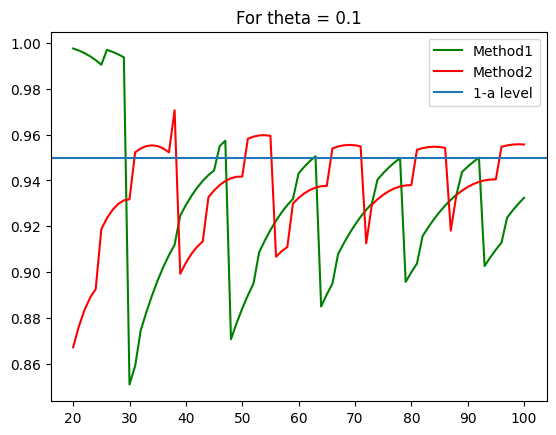

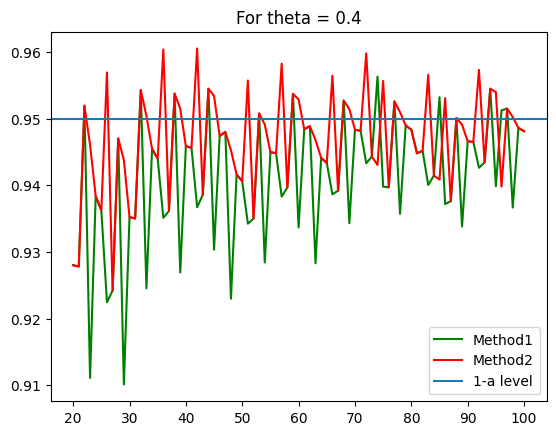

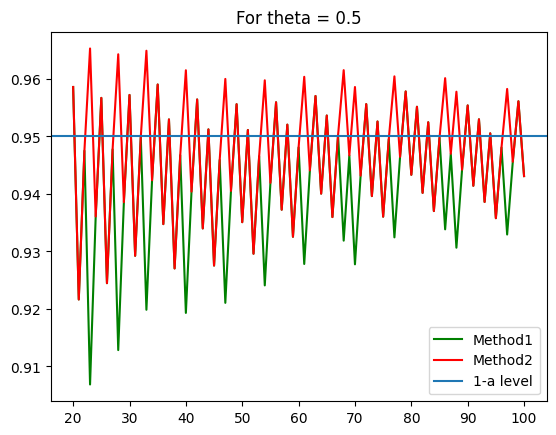

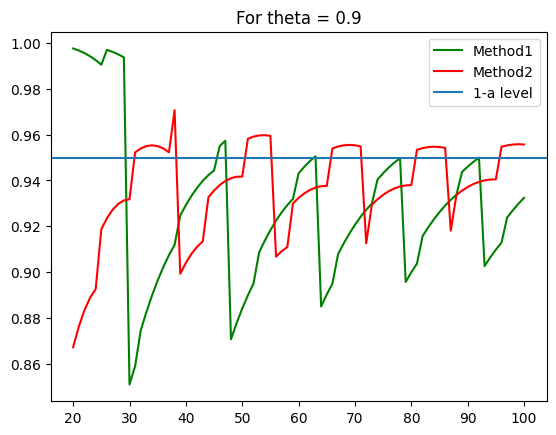

In [ ]:
def exact_cover1(n, theta, a=0.05):
  coverage = 0.0
  for k in range(n + 1):
    p_hat = k / n
    if p_hat == 0 or p_hat == 1:
      se = 1 / (2 * np.sqrt(n))
    else:
      se = np.sqrt(p_hat * (1 - p_hat) / n)

    z = stats.norm.ppf(1 - a/2)
    lower = p_hat - z * se
    upper = p_hat + z * se

    if lower <= theta <= upper:
      prob = stats.binom.pmf(k, n, theta)
      coverage += prob

  return coverage

def exact_cover2(n, theta, alpha=0.05):
  coverage = 0.0
  z = stats.norm.ppf(1 - alpha/2)

  for k in range(n + 1):
    p_hat = k / n

    if p_hat == 0:
      phi = 0
    elif p_hat == 1:
      phi = np.pi/2
    else:
      phi = np.arcsin(np.sqrt(p_hat))

    lower_phi = phi - z / (2 * np.sqrt(n))
    upper_phi = phi + z / (2 * np.sqrt(n))


    lower = (np.sin(lower_phi))**2
    upper = (np.sin(upper_phi))**2
    lower = max(0, lower)
    upper = min(1, upper)


    prob = stats.binom.pmf(k, n, theta)
    if lower <= theta <= upper:
      coverage += prob

  return coverage


n_vals = range(20,101)
theta_vals = [0.1, 0.4, 0.5, 0.9]
a = 0.05

cover1 = {theta :[] for theta in theta_vals}
cover2 = {theta :[] for theta in theta_vals}
for n in n_vals:
  for theta in theta_vals:
    cover1[theta].append(exact_cover1(n, theta, a))
    cover2[theta].append(exact_cover2(n, theta, a))

for theta in theta_vals:
  plt.plot(n_vals, cover1[theta], color = 'g', label = 'Method1')
  plt.plot(n_vals, cover2[theta], color = 'r', label = 'Method2')
  plt.title(f'For theta = {theta}')
  plt.axhline(y = 1-a, label='1-a level')
  plt.legend()
  plt.show()



4*)  X1, ..., Xn ∼ Gamma(θ, 1). Построить асимптотический доверительный интервал для θ на основе ОМП.

In [ ]:
from scipy.special import digamma, polygamma
from scipy.optimize import minimize_scalar

coverage = 0
n = 20
k = 1000
theta = 5
a=0.05

for i in range(k):
  x_data = stats.gamma.rvs(a = theta, scale = 1, size = n)
  x_ln = np.mean([np.log(i) for i in x_data])

  #solving equation digamma(thetha) = x_ln
  def equation(theta):
    return (digamma(theta) - x_ln) **2

  initial_guess = np.mean(x_data)
  result = minimize_scalar(equation, bounds=(1e-6, 100), method='bounded')
  theta_mle = result.x

  tri_theta = polygamma(1, theta_mle)
  quantile = stats.norm.ppf(1-a/2)
  theta1 = theta_mle - quantile/np.sqrt(n*tri_theta)
  theta2 = theta_mle + quantile/np.sqrt(n*tri_theta)

  if theta1<=theta<=theta2:
    coverage += 1

print(f'Coverage: {coverage/ k}')



Coverage: 0.938
